In [29]:
print(sentiment_df.head())

print("\n")
print(sentiment_df.columns.tolist())

print("\n")
print(sentiment_df.info())

    timestamp  value classification       date
0  1517463000     30           Fear 2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02
2  1517635800     40           Fear 2018-02-03
3  1517722200     24   Extreme Fear 2018-02-04
4  1517808600     11   Extreme Fear 2018-02-05


['timestamp', 'value', 'classification', 'date']


<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   str           
 3   date            2644 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 82.8 KB
None


In [30]:
# ============================================================
# ENSURE DATE TYPES MATCH
# ============================================================

trades_df["trade_date"] = pd.to_datetime(
    trades_df["trade_date"]
)

sentiment_df["date"] = pd.to_datetime(
    sentiment_df["date"]
)

print(trades_df["trade_date"].dtype)
print(sentiment_df["date"].dtype)

datetime64[s]
datetime64[us]


In [31]:
# ============================================================
# MERGE SENTIMENT WITH TRADES
# ============================================================

merged_df = trades_df.merge(
    sentiment_df,
    left_on="trade_date",
    right_on="date",
    how="left"
)

print("Merged Shape:", merged_df.shape)

display(
    merged_df.head()
)

Merged Shape: (211224, 24)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,trade_date,trade_hour,day_of_week,is_profitable,timestamp_y,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,3,Sunday,0,1.730007e+09,74.0,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,3,Sunday,0,1.730007e+09,74.0,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,3,Sunday,0,1.730007e+09,74.0,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,3,Sunday,0,1.730007e+09,74.0,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,3,Sunday,0,1.730007e+09,74.0,Greed,2024-10-27


In [32]:
# ============================================================
# CHECK MISSING SENTIMENT VALUES
# ============================================================

missing_sentiment = merged_df["classification"].isnull().sum()

print("Missing Sentiment Rows:", missing_sentiment)

Missing Sentiment Rows: 26961


In [33]:
print("TRADES DATE RANGE")
print(
    merged_df["trade_date"].min(),
    "->",
    merged_df["trade_date"].max()
)

print("\nSENTIMENT DATE RANGE")
print(
    sentiment_df["date"].min(),
    "->",
    sentiment_df["date"].max()
)

TRADES DATE RANGE
2023-03-28 00:00:00 -> 2025-06-15 00:00:00

SENTIMENT DATE RANGE
2018-02-01 00:00:00 -> 2025-05-02 00:00:00


In [34]:
missing_dates = merged_df[
    merged_df["classification"].isnull()
]["trade_date"]

print(
    missing_dates
    .value_counts()
    .sort_index()
    .tail(20)
)

trade_date
2025-06-15    26961
Name: count, dtype: int64


In [35]:
# ============================================================
# REMOVE ROWS WITHOUT SENTIMENT DATA
# ============================================================

merged_df = merged_df[
    merged_df["classification"].notnull()
].copy()

print("New Shape:", merged_df.shape)

New Shape: (184263, 24)


In [36]:
missing_sentiment = merged_df["classification"].isnull().sum()

print("Missing Sentiment Rows:", missing_sentiment)

Missing Sentiment Rows: 0


classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


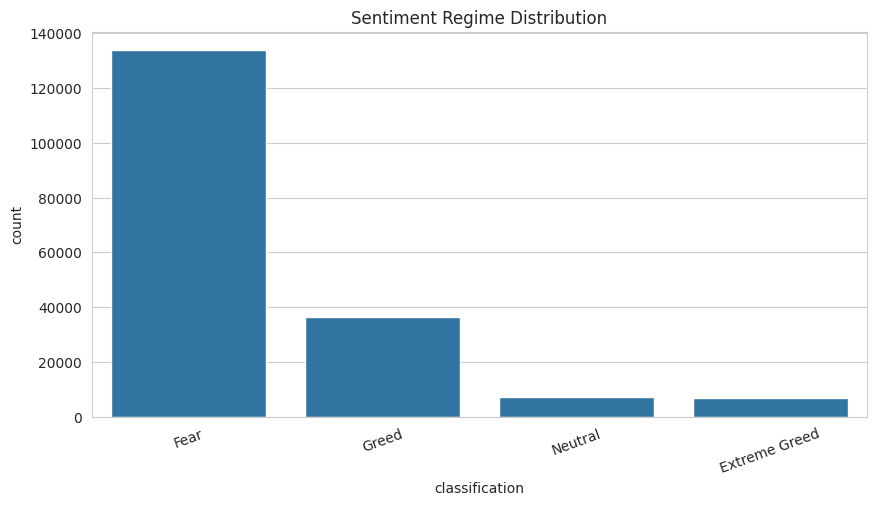

In [37]:
# ============================================================
# SENTIMENT REGIME COUNTS
# ============================================================

print(
    merged_df["classification"]
    .value_counts()
)

plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x="classification",
    order=merged_df["classification"].value_counts().index
)

plt.title("Sentiment Regime Distribution")

plt.xticks(rotation=20)

plt.show()

In [38]:
# ============================================================
# PNL BY SENTIMENT REGIME
# ============================================================

sentiment_pnl = (
    merged_df
    .groupby("classification")["closed_pnl"]
    .agg(["mean", "median", "sum", "count"])
    .sort_values("mean", ascending=False)
)

display(sentiment_pnl)

,mean,median,sum,count
classification,,,,
Greed,87.894859,0.0,3.189617e+06,36289
Fear,50.047622,0.0,6.699925e+06,133871
Extreme Greed,25.418772,0.0,1.769655e+05,6962
Neutral,22.229713,0.0,1.587424e+05,7141


In [39]:
# ============================================================
# TRADING SIZE UNDER DIFFERENT SENTIMENTS
# ============================================================

sentiment_volume = (
    merged_df
    .groupby("classification")["size_usd"]
    .agg(["mean", "median", "sum"])
    .sort_values("mean", ascending=False)
)

display(sentiment_volume)

,mean,median,sum
classification,,,
Extreme Greed,5660.265764,1148.635,3.940677e+07
Fear,5259.977837,605.070,7.041585e+08
Greed,3182.883845,499.940,1.155037e+08
Neutral,3058.848110,554.160,2.184323e+07


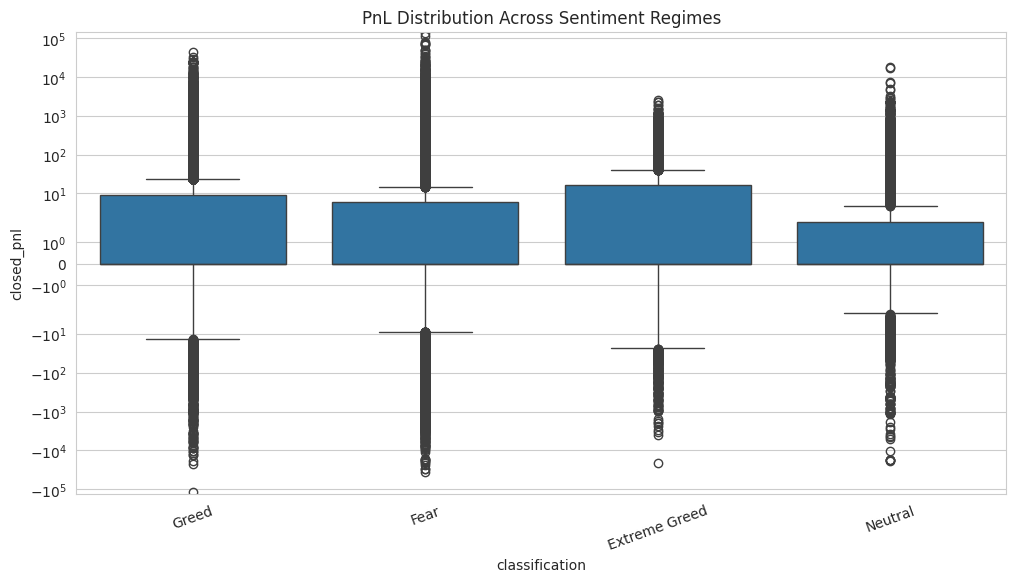

In [40]:
# ============================================================
# PNL DISTRIBUTION BY SENTIMENT
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged_df,
    x="classification",
    y="closed_pnl"
)

plt.yscale("symlog")

plt.title("PnL Distribution Across Sentiment Regimes")

plt.xticks(rotation=20)

plt.show()

In [41]:
# ============================================================
# TRADER BEHAVIOR UNDER SENTIMENT REGIMES
# ============================================================

trader_sentiment = (
    merged_df
    .groupby(["account", "classification"])
    .agg(
        total_pnl=("closed_pnl", "sum"),
        avg_pnl=("closed_pnl", "mean"),
        total_volume=("size_usd", "sum"),
        avg_size=("size_usd", "mean"),
        win_rate=("is_profitable", "mean"),
        trades=("account", "count")
    )
    .reset_index()
)

trader_sentiment["win_rate"] *= 100

display(trader_sentiment.head())

,account,classification,total_pnl,avg_pnl,total_volume,avg_size,win_rate,trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1.927736e+06,574.414696,54854631.95,16345.241940,40.554231,3356
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,-3.275059e+05,-708.887230,6842632.02,14810.891818,2.597403,462
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Fear,1.709873e+04,4.839719,5982611.50,1693.351684,43.504104,3533
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Greed,2.060745e+04,64.398269,797679.97,2492.749906,53.125000,320
4,0x271b280974205ca63b716753467d5a371de622ab,Fear,2.997093e+04,26.382859,12310719.50,10836.900968,43.045775,1136


In [42]:
# ============================================================
# FEAR REGIME PERFORMANCE
# ============================================================

fear_traders = (
    trader_sentiment[
        trader_sentiment["classification"]
        .isin(["Fear", "Extreme Fear"])
    ]
)

fear_alpha = (
    fear_traders
    .groupby("account")
    .agg(
        fear_pnl=("total_pnl", "sum"),
        fear_win_rate=("win_rate", "mean"),
        fear_trades=("trades", "sum")
    )
    .reset_index()
)

fear_alpha = fear_alpha.sort_values(
    "fear_pnl",
    ascending=False
)

display(
    fear_alpha.head(20)
)

,account,fear_pnl,fear_win_rate,fear_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.927736e+06,40.554231,3356
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401572e+05,46.753185,21190
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.133278e+05,49.527063,3806
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5.538180e+05,39.105691,7380
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,4.035016e+05,41.561364,5777
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.419454e+05,39.616613,939
30,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,3.254420e+05,37.222976,2211
12,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2.239684e+05,39.175809,3737
19,0x8170715b3b381dffb7062c0298972d4727a0a63b,1.963038e+05,28.763089,3056
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.834030e+05,24.418605,258


In [43]:
from scipy.stats import f_oneway

# ============================================================
# PNL GROUPS
# ============================================================

fear_pnl = merged_df[
    merged_df["classification"] == "Fear"
]["closed_pnl"]

greed_pnl = merged_df[
    merged_df["classification"] == "Greed"
]["closed_pnl"]

extreme_greed_pnl = merged_df[
    merged_df["classification"] == "Extreme Greed"
]["closed_pnl"]

neutral_pnl = merged_df[
    merged_df["classification"] == "Neutral"
]["closed_pnl"]

# ============================================================
# ANOVA TEST
# ============================================================

anova_result = f_oneway(
    fear_pnl,
    greed_pnl,
    extreme_greed_pnl,
    neutral_pnl
)

print("ANOVA RESULT")
print(anova_result)

ANOVA RESULT
F_onewayResult(statistic=np.float64(21.33042041351791), pvalue=np.float64(8.287959254096799e-14))


In [44]:
from scipy.stats import kruskal

kruskal_result = kruskal(
    fear_pnl,
    greed_pnl,
    extreme_greed_pnl,
    neutral_pnl
)

print("KRUSKAL RESULT")
print(kruskal_result)

KRUSKAL RESULT
KruskalResult(statistic=np.float64(386.54799025444476), pvalue=np.float64(1.814810923882187e-83))


In [45]:
from scipy.stats import shapiro, levene

# ============================================================
# NORMALITY CHECK (SHAPIRO-WILK)
# ============================================================

# Shapiro breaks down on very large samples, so each group is
# sampled down before testing

groups = {
    "Fear": fear_pnl,
    "Greed": greed_pnl,
    "Extreme Greed": extreme_greed_pnl,
    "Neutral": neutral_pnl
}

for name, group in groups.items():

    sample = group.sample(
        min(len(group), 5000),
        random_state=42
    )

    stat, p = shapiro(sample)

    print(name, "-> Shapiro p-value:", p)

# ============================================================
# EQUAL VARIANCE CHECK (LEVENE'S TEST)
# ============================================================

levene_result = levene(
    fear_pnl,
    greed_pnl,
    extreme_greed_pnl,
    neutral_pnl
)

print("\nLEVENE RESULT")
print(levene_result)

Fear -> Shapiro p-value: 1.0647828091697107e-93
Greed -> Shapiro p-value: 2.6394447480482144e-93
Extreme Greed -> Shapiro p-value: 2.9482111458324643e-93
Neutral -> Shapiro p-value: 6.303072565608039e-94

LEVENE RESULT
LeveneResult(statistic=np.float64(25.749942254488534), pvalue=np.float64(1.2029422052934665e-16))


In [46]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================
# EFFECT SIZE FOR ANOVA (ETA SQUARED)
# ============================================================

all_pnl = pd.concat([
    fear_pnl,
    greed_pnl,
    extreme_greed_pnl,
    neutral_pnl
])

grand_mean = all_pnl.mean()

group_sizes = [len(fear_pnl), len(greed_pnl), len(extreme_greed_pnl), len(neutral_pnl)]
group_means = [fear_pnl.mean(), greed_pnl.mean(), extreme_greed_pnl.mean(), neutral_pnl.mean()]

ss_between = 0

for size, mean in zip(group_sizes, group_means):
    ss_between += size * (mean - grand_mean) ** 2

ss_total = ((all_pnl - grand_mean) ** 2).sum()

eta_squared = ss_between / ss_total

print("Eta Squared:", eta_squared)

# ============================================================
# TUKEY HSD POST-HOC TEST
# ============================================================

tukey_data = merged_df[
    merged_df["classification"].isin(
        ["Fear", "Greed", "Extreme Greed", "Neutral"]
    )
]

tukey_result = pairwise_tukeyhsd(
    endog=tukey_data["closed_pnl"],
    groups=tukey_data["classification"],
    alpha=0.05
)

print(tukey_result)

Eta Squared: 0.0003471691773375213
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1     group2 meandiff p-adj   lower    upper   reject
--------------------------------------------------------------
Extreme Greed    Fear  24.6288 0.1415  -4.9838  54.2415  False
Extreme Greed   Greed  62.4761    0.0  30.9567  93.9955   True
Extreme Greed Neutral  -3.1891 0.9971 -43.7627  37.3846  False
         Fear   Greed  37.8472    0.0  23.5901  52.1044   True
         Fear Neutral -27.8179 0.0693 -57.0756   1.4398  False
        Greed Neutral -65.6651    0.0 -96.8514 -34.4789   True
--------------------------------------------------------------


In [47]:
correlation = merged_df[
    ["value", "closed_pnl"]
].corr()

print(correlation)

               value  closed_pnl
value       1.000000    0.011132
closed_pnl  0.011132    1.000000


In [48]:
from scipy.stats import ttest_ind

fear_sizes = merged_df[
    merged_df["classification"].isin(["Fear", "Extreme Fear"])
]["size_usd"]

greed_sizes = merged_df[
    merged_df["classification"].isin(["Greed", "Extreme Greed"])
]["size_usd"]

size_test = ttest_ind(
    greed_sizes,
    fear_sizes,
    equal_var=False
)

print(size_test)

TtestResult(statistic=np.float64(-16.6685730268805), pvalue=np.float64(2.479948630341251e-62), df=np.float64(174129.16486199189))


In [49]:
# ============================================================
# EFFECT SIZE AND CONFIDENCE INTERVAL FOR T-TEST
# ============================================================

pooled_std = np.sqrt(
    (
        (greed_sizes.std() ** 2) + (fear_sizes.std() ** 2)
    ) / 2
)

cohens_d = (
    greed_sizes.mean() - fear_sizes.mean()
) / pooled_std

mean_diff = greed_sizes.mean() - fear_sizes.mean()

se_diff = np.sqrt(
    (greed_sizes.var() / len(greed_sizes)) +
    (fear_sizes.var() / len(fear_sizes))
)

ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff

print("Cohen's D:", cohens_d)
print("Mean Difference:", mean_diff)
print("95% Confidence Interval:", (ci_lower, ci_upper))

Cohen's D: -0.07218577515182809
Mean Difference: -1678.3163236948121
95% Confidence Interval: (np.float64(-1875.6637504443624), np.float64(-1480.9688969452618))


In [50]:
from scipy.stats import chi2_contingency

# ============================================================
# CHI-SQUARE TEST - WIN RATE ACROSS SENTIMENT REGIMES
# ============================================================

win_contingency = pd.crosstab(
    merged_df["classification"],
    merged_df["is_profitable"]
)

print(win_contingency)

chi2_stat, chi2_p, dof, expected = chi2_contingency(win_contingency)

print("\nChi-Square Statistic:", chi2_stat)
print("P-Value:", chi2_p)
print("Degrees of Freedom:", dof)

# ============================================================
# EFFECT SIZE FOR CHI-SQUARE (CRAMER'S V)
# ============================================================

n = win_contingency.sum().sum()

min_dim = min(win_contingency.shape) - 1

cramers_v = (chi2_stat / (n * min_dim)) ** 0.5

print("Cramer's V:", cramers_v)

is_profitable       0      1
classification              
Extreme Greed    3550   3412
Fear            78295  55576
Greed           20087  16202
Neutral          4876   2265

Chi-Square Statistic: 567.4065044816895
P-Value: 1.171908380060481e-122
Degrees of Freedom: 3
Cramer's V: 0.055491707214607985


In [51]:
# ============================================================
# A/A TEST - SANITY CHECK ON THE TESTING PIPELINE
# ============================================================

# Splits ONE regime (Neutral) into two random halves and runs
# the same test used for the real comparisons. Both halves come
# from the same regime, so this should NOT come back significant.
# If it does, something in the pipeline (grouping, variance,
# sample size) is producing false positives.

neutral_only = merged_df[
    merged_df["classification"] == "Neutral"
].copy()

neutral_only["random_group"] = np.random.RandomState(42).randint(
    0,
    2,
    size=len(neutral_only)
)

group_a = neutral_only[
    neutral_only["random_group"] == 0
]["closed_pnl"]

group_b = neutral_only[
    neutral_only["random_group"] == 1
]["closed_pnl"]

aa_result = ttest_ind(
    group_a,
    group_b,
    equal_var=False
)

print("A/A TEST RESULT (should NOT be significant)")
print(aa_result)

A/A TEST RESULT (should NOT be significant)
TtestResult(statistic=np.float64(1.8050127239371268), pvalue=np.float64(0.07111499655693145), df=np.float64(7107.231101920881))
